## Midterm Machine Learning - Clustering

### Rafly Fasha Purnomo Putra - 1103223050

### Eksplorasi Data

Sebelum masuk ke tahap pembersihan data (penanganan nilai hilang), berikut adalah langkah-langkah yang telah dilakukan:

1. **Environment Setup**: Mengimpor pustaka utama seperti `pandas` untuk manipulasi data, serta `matplotlib` dan `seaborn` untuk keperluan visualisasi.
2. **Load Data**: Mengambil data dari file `clusteringmidterm.csv`.
3. **Analisis Awal**:
   * Kita memeriksa **5 baris pertama** untuk memahami struktur kolom dan jenis informasi yang tersedia (misalnya saldo, frekuensi pembelian, dll).
   * Menggunakan `.info()`, kita mengidentifikasi struktur teknis data, termasuk jumlah baris (8950) dan menemukan bahwa kolom `CREDIT_LIMIT` serta `MINIMUM_PAYMENTS` memiliki nilai kosong yang perlu diperbaiki.
   * Menggunakan `.describe()`, kita melihat ringkasan statistik untuk memahami rentang nilai pada setiap fitur, yang memberikan petunjuk awal mengenai keberadaan *outlier*.

In [60]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Memuat dataset
df = pd.read_csv('/content/clusteringmidterm.csv')

# Menampilkan 5 baris pertama dataset
print("5 Baris pertama dataset:")
display(df.head())


5 Baris pertama dataset:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [61]:
# Menampilkan informasi umum dataset (tipe data, nilai non-null)
print("Informasi dataset:")
display(df.info())


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   

None

In [62]:
# Menampilkan statistik deskriptif dataset
print("Statistik deskriptif dataset:")
display(df.describe())


Statistik deskriptif dataset:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Handling Missing Value

Dari eksplorasi awal (`df.info()`), ditemukan bahwa kolom `CREDIT_LIMIT` dan `MINIMUM_PAYMENTS` memiliki nilai yang hilang. Kita akan mengisi nilai yang hilang ini menggunakan nilai median dari masing-masing kolom.

In [63]:
# Memeriksa jumlah nilai yang hilang per kolom
print("Jumlah nilai yang hilang sebelum imputasi:")
display(df.isnull().sum())

# Mengisi nilai yang hilang menggunakan assignment (menghindari FutureWarning)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

# Menghapus kolom CUST_ID karena tidak relevan untuk klastering
df_clustering = df.drop('CUST_ID', axis=1)

print("\nJumlah nilai yang hilang setelah imputasi:")
display(df_clustering.isnull().sum())

Jumlah nilai yang hilang sebelum imputasi:


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0



Jumlah nilai yang hilang setelah imputasi:


,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


### Handling Outlier

Dataset kartu kredit sering kali memiliki nilai ekstrem (outlier) pada kolom seperti `BALANCE` atau `PURCHASES`. Kita akan membatasi (*capping*) nilai-nilai ini pada persentil ke-99 untuk menjaga stabilitas model K-Means.

Penanganan outlier selesai menggunakan metode clipping pada persentil 99.


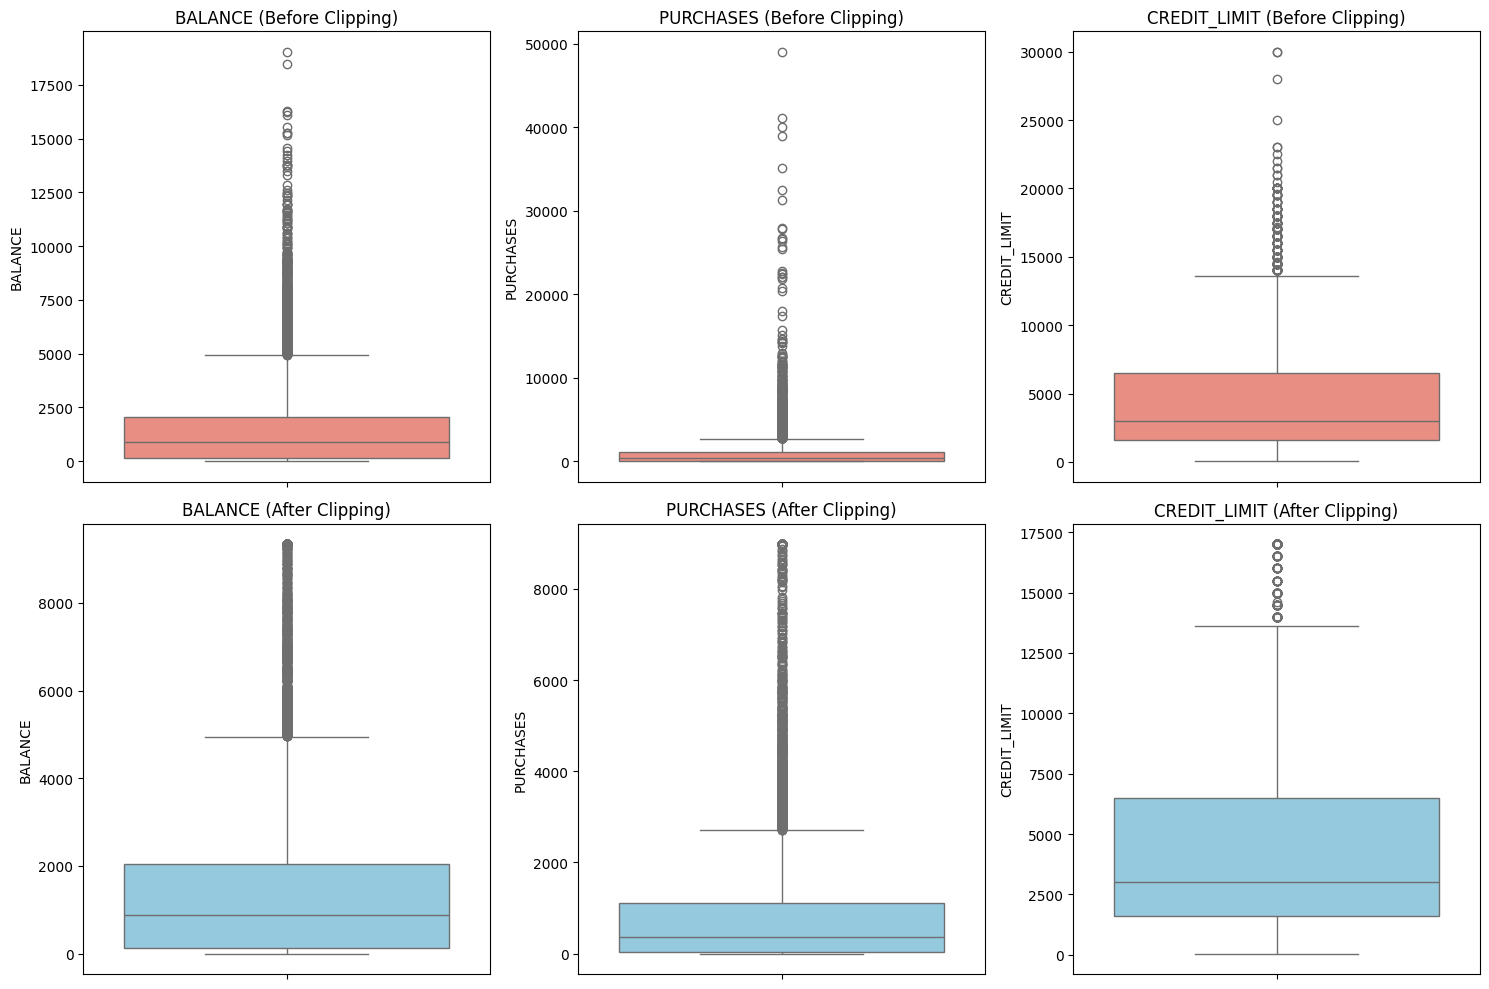

In [71]:
# Menyimpan data sebelum clipping untuk perbandingan
df_before = df_clustering.copy()

# Menangani outlier dengan membatasi nilai pada persentil ke-99
for col in df_clustering.columns:
    upper_limit = df_clustering[col].quantile(0.99)
    df_clustering[col] = df_clustering[col].clip(upper=upper_limit)

print("Penanganan outlier selesai menggunakan metode clipping pada persentil 99.")

# Visualisasi Before vs After pada fitur-fitur kunci
features_to_show = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_show):
    # Boxplot Sebelum Clipping
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_before[col], color='salmon')
    plt.title(f'{col} (Before Clipping)')

    # Boxplot Sesudah Clipping
    plt.subplot(2, 3, i + 4)
    sns.boxplot(y=df_clustering[col], color='skyblue')
    plt.title(f'{col} (After Clipping)')

plt.tight_layout()
plt.show()

## Preprocessing Data: Menghapus Kolom Identifikasi dan Penskalaan Fitur

Sebelum menerapkan algoritma klastering, kita perlu menghapus kolom identifikasi (`CUST_ID`) karena tidak relevan untuk proses klastering. Selain itu, fitur-fitur numerik perlu diskalakan agar memiliki rentang nilai yang seragam, karena banyak algoritma klastering (seperti K-Means) sensitif terhadap skala fitur. Kita akan menggunakan `StandardScaler` untuk melakukan penskalaan.

In [65]:
# Menghapus kolom CUST_ID karena tidak relevan untuk klastering
df_clustering = df.drop('CUST_ID', axis=1)

# Menampilkan 5 baris pertama dataset setelah menghapus CUST_ID
print("5 Baris pertama dataset setelah menghapus CUST_ID:")
display(df_clustering.head())

5 Baris pertama dataset setelah menghapus CUST_ID:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [66]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Menerapkan penskalaan pada semua fitur numerik
df_scaled = scaler.fit_transform(df_clustering)

# Mengubah kembali array hasil penskalaan menjadi DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns)

# Menampilkan 5 baris pertama dari DataFrame yang sudah diskalakan
print("5 Baris pertama dataset setelah penskalaan (StandardScaler):")
display(df_scaled.head())

5 Baris pertama dataset setelah penskalaan (StandardScaler):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## Cluster Optimization and Selection (Elbow Method)

Untuk menentukan jumlah klaster yang optimal (`k`) untuk algoritma K-Means, kita akan menggunakan metode Elbow Method. Metode ini melibatkan perhitungan Within-Cluster Sum of Squares (WCSS) untuk berbagai jumlah klaster dan mencari "titik siku" pada plot yang menunjukkan penurunan WCSS yang mulai melambat.

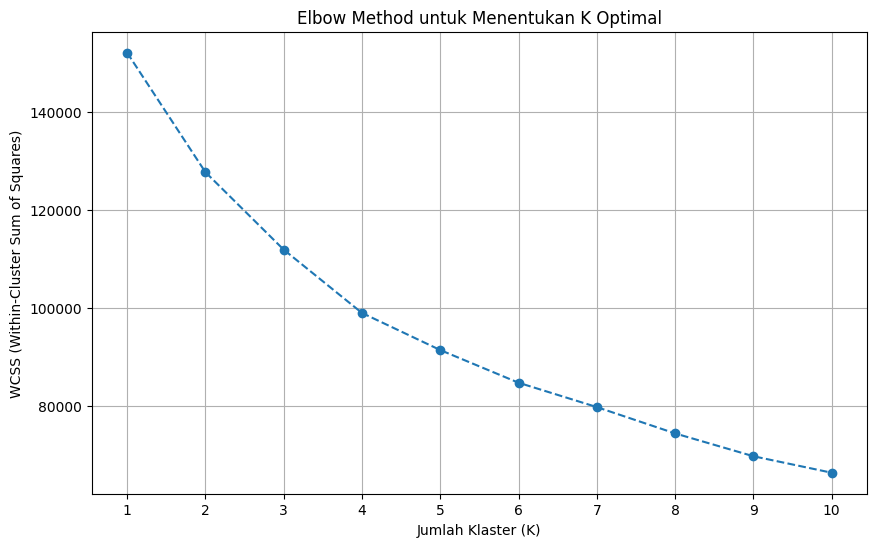

In [67]:
# Menentukan rentang jumlah klaster yang akan diuji
wcss = []
max_k = 10 # Kita bisa mencoba hingga 10 klaster

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

### Comparison Silhouette Score (K=2 hingga 10)

Selain metode Elbow, kita akan melihat Silhouette Score untuk setiap jumlah klaster untuk membantu memvalidasi pemilihan K.

Untuk n_clusters = 2, rata-rata Silhouette Score: 0.2100
Untuk n_clusters = 3, rata-rata Silhouette Score: 0.2510
Untuk n_clusters = 4, rata-rata Silhouette Score: 0.1977
Untuk n_clusters = 5, rata-rata Silhouette Score: 0.1931
Untuk n_clusters = 6, rata-rata Silhouette Score: 0.2029
Untuk n_clusters = 7, rata-rata Silhouette Score: 0.2077
Untuk n_clusters = 8, rata-rata Silhouette Score: 0.2217
Untuk n_clusters = 9, rata-rata Silhouette Score: 0.2260
Untuk n_clusters = 10, rata-rata Silhouette Score: 0.2204


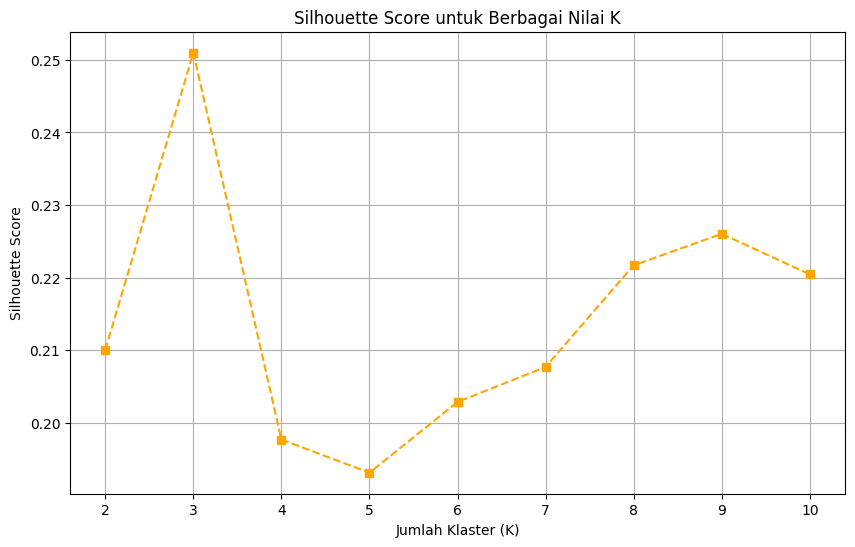

In [68]:
sil_scores = []
range_n_clusters = list(range(2, 11))

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(df_scaled)

    # Menghitung rata-rata silhouette score
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    sil_scores.append(silhouette_avg)
    print(f"Untuk n_clusters = {n_clusters}, rata-rata Silhouette Score: {silhouette_avg:.4f}")

# Visualisasi Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, sil_scores, marker='s', color='orange', linestyle='--')
plt.title('Silhouette Score untuk Berbagai Nilai K')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## K-Means Clustering Implementation and Evaluation

Berdasarkan hasil perbandingan, kita memilih **K=3** sebagai jumlah klaster optimal. Hal ini didukung oleh:
1. **Silhouette Score:** K=3 menghasilkan skor tertinggi (0.2510), menunjukkan pemisahan antar klaster yang paling baik.
2. **Elbow Method:** Titik siku mulai melandai secara konsisten setelah K=3.

In [69]:
# Menerapkan K-Means dengan K=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Menambahkan label klaster
df['Cluster'] = clusters
df_scaled['Cluster'] = clusters

print(f"K-Means Clustering berhasil diterapkan dengan {k_optimal} klaster.")
display(df['Cluster'].value_counts().sort_index())

K-Means Clustering berhasil diterapkan dengan 3 klaster.


,count
Cluster,
0,1275
1,6114
2,1561


## Cluster Profiling and Interpretation
Setelah menerapkan algoritma K-Means Clustering, langkah selanjutnya adalah menganalisis karakteristik setiap klaster dengan melihat nilai rata-rata dari seluruh fitur pada masing-masing kelompok. Proses ini dikenal sebagai cluster profiling, yang bertujuan untuk mengidentifikasi pola perilaku dan karakteristik finansial pelanggan pada setiap segmen.

Selain itu, Principal Component Analysis (PCA) digunakan untuk mereduksi data berdimensi tinggi menjadi dua komponen utama agar dapat divisualisasikan dengan lebih mudah. Visualisasi scatter plot 2D yang dihasilkan memberikan gambaran mengenai distribusi dan pemisahan antar klaster pelanggan.

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2182.352833,0.981702,4187.017796,2663.995153,1523.493231,449.753140,0.948175,0.664780,0.739630,0.062415,1.507451,55.692549,7642.784314,4075.533648,1227.915879,0.298766,11.916863
1,807.722510,0.834577,496.062522,247.273214,249.110368,338.996760,0.460353,0.129191,0.342052,0.069563,1.236833,8.480046,3267.022176,907.446164,530.068546,0.154115,11.475793
2,4023.788865,0.959193,389.051448,252.333261,136.797412,3917.254973,0.233899,0.111806,0.145661,0.451410,12.551570,5.636131,6729.471201,3053.943771,1765.204181,0.033673,11.353619


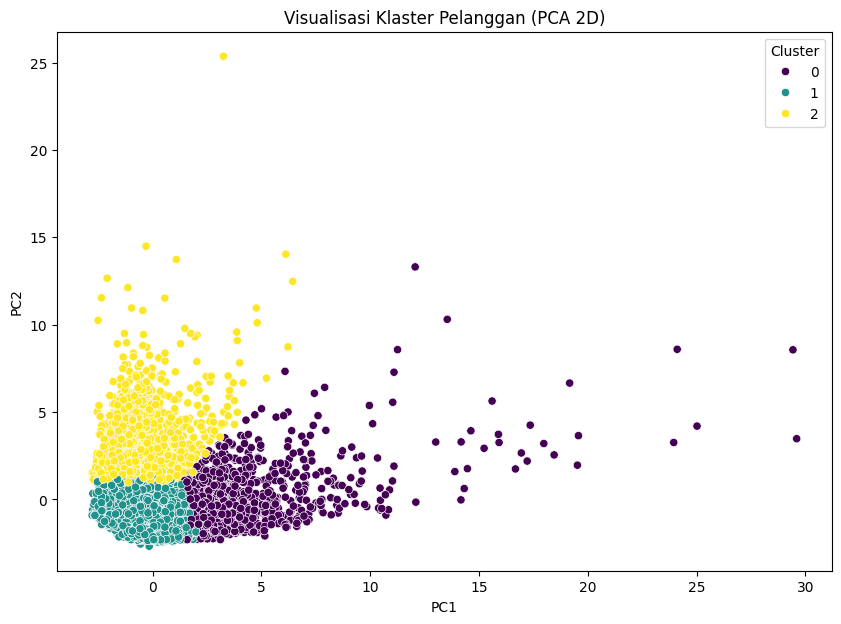

In [70]:
# Profiling dan Interpretasi Klaster
cluster_profiles = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()
display(cluster_profiles)

# Visualisasi 2D menggunakan PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled.drop('Cluster', axis=1))
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis')
plt.title('Visualisasi Klaster Pelanggan (PCA 2D)')
plt.show()

### Interpretasi Profil Klaster Pelanggan

Berdasarkan data rata-rata profil klaster, berikut adalah ringkasan karakteristik setiap kelompok:

*   **Cluster 0 (Spender VIP):** Kelompok pelanggan dengan aktivitas transaksi yang sangat tinggi. Mereka memiliki nilai PURCHASES, PURCHASES_TRX, dan CREDIT_LIMIT yang tinggi, serta aktif menggunakan fitur cicilan. Segmen ini merupakan pelanggan bernilai tinggi (high-value customers) dengan penggunaan kartu kredit yang intensif dan loyalitas tinggi.
*   **Cluster 1 (Budget):** Segmen pelanggan dengan saldo, transaksi, dan frekuensi penggunaan kartu yang paling rendah. Mereka dikategorikan sebagai pengguna pasif atau sangat hemat.
*   **Cluster 2 (Cash Advance Dependent):** Kelompok pelanggan dengan BALANCE dan CASH_ADVANCE yang sangat tinggi, tetapi aktivitas pembelian relatif rendah. Mereka lebih sering menggunakan fasilitas penarikan tunai dibandingkan transaksi pembelian biasa, serta memiliki rasio full payment yang sangat rendah. Segmen ini dapat mencerminkan pelanggan dengan ketergantungan terhadap cash advance atau pola penggunaan kredit berisiko lebih tinggi.